# 🏬 Dark Store Operations Simulator
## Notebook 3 — Executive Insights, Predictive Risk & Scenario Analysis

**Objective:**
This notebook converts operational data into board-level business decisions. It moves beyond descriptive reporting (what happened) into **diagnostic** (why), **predictive** (what's next), and **prescriptive** (what to do) analytics.

**Structure:**
| # | Section | Type |
|---|---------|------|
| 1 | Setup & Data Load | Foundation |
| 2 | Executive KPI Dashboard | Descriptive |
| 3 | Revenue Leakage Diagnosis | Diagnostic |
| 4 | AI-Based Store Risk Scoring | Diagnostic |
| 5 | Demand Forecasting (Statistical) | Predictive |
| 6 | Stockout Prediction (Logistic Regression) | Predictive |
| 7 | Scenario Stress-Test (+20% / −20% Demand) | Predictive |
| 8 | Capacity Planning Model | Prescriptive |
| 9 | Scenario Comparison Table | Prescriptive |
| 10 | Executive KPI Simulator | Prescriptive |
| 11 | Business Case Generator (Cost / Benefit / ROI) | Prescriptive |
| 12 | Final Executive Summary | Leadership Brief |

**Dataset:** 25,000 orders across 8 dark stores in 5 cities (Mumbai, Delhi, Pune, Bangalore, Hyderabad), Jan–Dec 2024. Inventory snapshot across 7 product categories.


---
## 1. Setup & Data Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.facecolor"] = "white"

DATA_DIR = "/Users/sumitkumargupta/Desktop/5_project/01_Data"

orders = pd.read_csv(
    os.path.join(DATA_DIR, "orders.csv"),
    parse_dates=["order_timestamp"]
)

inventory = pd.read_csv(os.path.join(DATA_DIR, "inventory.csv"))

min_date = orders["order_timestamp"].min().date()
max_date = orders["order_timestamp"].max().date()

print(f"Orders     : {orders.shape[0]:,} rows × {orders.shape[1]} columns")
print(f"Inventory  : {inventory.shape[0]:,} rows × {inventory.shape[1]} columns")
print(f"Date range : {min_date} to {max_date}")
print(f"Stores     : {orders['store_id'].nunique()}")
print(f"Cities     : {orders['city'].nunique()}")
print(f"Categories : {orders['category'].nunique()}")

Orders     : 25,000 rows × 19 columns
Inventory  : 56 rows × 7 columns
Date range : 2024-01-01 to 2024-12-30
Stores     : 8
Cities     : 5
Categories : 7


---
## 2. Executive KPI Dashboard

**SLA definition (data-derived, not assumed):** cross-checking `total_fulfillment_time_min` against `sla_breached` shows a clean split at **30 minutes** (breached orders start at 30.1 min, on-time orders max out at 30.0 min). This confirms the operational SLA is **30 minutes end-to-end**, and this threshold is reused consistently in every scenario/forecast section below.

In [3]:
SLA_THRESHOLD_MIN = 30  # confirmed empirically below

check = orders.groupby("sla_breached")["total_fulfillment_time_min"].agg(["min", "max"])
check.columns = ["min_fulfillment_min", "max_fulfillment_min"]
print("SLA threshold sanity check:")
print(check)

SLA threshold sanity check:
              min_fulfillment_min  max_fulfillment_min
sla_breached                                          
0                           10.10                30.00
1                           30.10                61.40


In [4]:
executive_kpi = pd.DataFrame({
    "Metric": [
        "Total Orders", "Total Revenue (INR)", "Avg Order Value (INR)",
        "SLA Breach %", "Stockout %", "Cancellation %", "Avg Customer Rating"
    ],
    "Value": [
        f"{len(orders):,}",
        f"₹{orders['revenue_inr'].sum():,.0f}",
        f"₹{orders['revenue_inr'].mean():,.2f}",
        f"{orders['sla_breached'].mean()*100:.2f}%",
        f"{orders['stockout_flag'].mean()*100:.2f}%",
        f"{orders['cancelled_flag'].mean()*100:.2f}%",
        f"{orders['customer_rating'].mean():.2f} / 5"
    ]
})
executive_kpi

,Metric,Value
0,Total Orders,"25,000"
1,Total Revenue (INR),"₹24,162,205"
2,Avg Order Value (INR),₹966.49
3,SLA Breach %,62.81%
4,Stockout %,15.17%
5,Cancellation %,6.08%
6,Avg Customer Rating,3.89 / 5


---
## 3. Revenue Leakage Diagnosis

Revenue lost specifically to **stockout-driven cancellations** — orders that were both stocked out *and* cancelled, i.e. demand the store could not fulfil.

In [5]:
lost_revenue = orders[
    (orders["stockout_flag"] == 1) & (orders["cancelled_flag"] == 1)
]["revenue_inr"].sum()

lost_pct = (lost_revenue / orders["revenue_inr"].sum()) * 100

print(f"Revenue Lost to Stockout-Driven Cancellations : ₹{lost_revenue:,.0f}")
print(f"As % of Total Revenue                         : {lost_pct:.2f}%")

Revenue Lost to Stockout-Driven Cancellations : ₹1,469,771
As % of Total Revenue                         : 6.08%


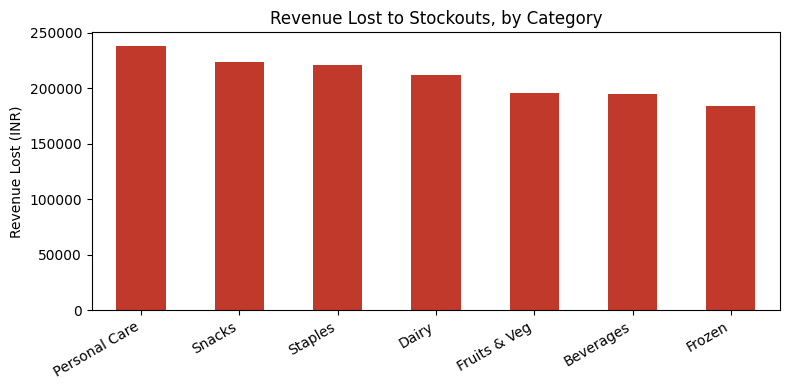

category
Personal Care   238,348.91
Snacks          223,985.16
Staples         220,678.06
Dairy           211,978.23
Fruits & Veg    196,077.77
Beverages       194,675.41
Frozen          184,027.03
Name: revenue_inr, dtype: float64

In [6]:
lost_revenue_by_category = orders[
    (orders["stockout_flag"] == 1) & (orders["cancelled_flag"] == 1)
].groupby("category")["revenue_inr"].sum().sort_values(ascending=False)

lost_revenue_by_category.plot(kind="bar", figsize=(8, 4), color="#c0392b")
plt.title("Revenue Lost to Stockouts, by Category")
plt.ylabel("Revenue Lost (INR)")
plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

lost_revenue_by_category

---
## 4. AI-Based Store Risk Scoring

A weighted composite risk score per store, blending three operational failure modes. Weights reflect business priority: SLA breaches hurt every order (highest weight), stockouts are the second-biggest driver of lost revenue, and cancellations are the downstream symptom.

`risk_score = 0.5·(SLA breach rate) + 0.3·(stockout rate) + 0.2·(cancellation rate)`, scaled to 0–100 and reported alongside each store's raw rates and inventory health (`% categories below reorder point`) for full auditability.

In [7]:
store_risk = orders.groupby("store_id").agg(
    sla_breach_rate=("sla_breached", "mean"),
    stockout_rate=("stockout_flag", "mean"),
    cancel_rate=("cancelled_flag", "mean"),
    total_orders=("order_id", "count"),
    total_revenue=("revenue_inr", "sum"),
)

store_risk["risk_score"] = (
    store_risk["sla_breach_rate"] * 50 +
    store_risk["stockout_rate"] * 30 +
    store_risk["cancel_rate"] * 20
).round(1)

# Enrich with inventory health per store
inv_health = inventory.groupby("store_id")["below_reorder"].mean().rename("pct_categories_below_reorder")
store_risk = store_risk.join(inv_health)

store_risk = store_risk.sort_values("risk_score", ascending=False)
store_risk.style.format({
    "sla_breach_rate": "{:.1%}", "stockout_rate": "{:.1%}", "cancel_rate": "{:.1%}",
    "total_revenue": "₹{:,.0f}", "pct_categories_below_reorder": "{:.1%}"
})

,sla_breach_rate,stockout_rate,cancel_rate,total_orders,total_revenue,risk_score,pct_categories_below_reorder
store_id,,,,,,,
DS_Mumbai_Andheri,63.4%,15.5%,6.3%,3112,"₹3,072,395",37.600000,28.6%
DS_Pune_Kothrud,63.1%,15.8%,6.6%,3243,"₹3,096,914",37.600000,28.6%
DS_Mumbai_BKC,63.0%,15.2%,6.5%,3100,"₹2,999,790",37.400000,14.3%
DS_Delhi_CP,62.9%,15.3%,5.7%,3124,"₹3,003,380",37.100000,0.0%
DS_Delhi_Lajpat,62.7%,15.4%,6.0%,3136,"₹3,017,359",37.100000,28.6%
DS_Bangalore_Whitefield,62.2%,15.4%,6.3%,3049,"₹2,932,357",37.000000,14.3%
DS_Bangalore_Koramangala,62.9%,14.4%,5.5%,3129,"₹3,028,914",36.900000,28.6%
DS_Hyderabad_Hitech,62.4%,14.4%,5.7%,3107,"₹3,011,096",36.600000,14.3%


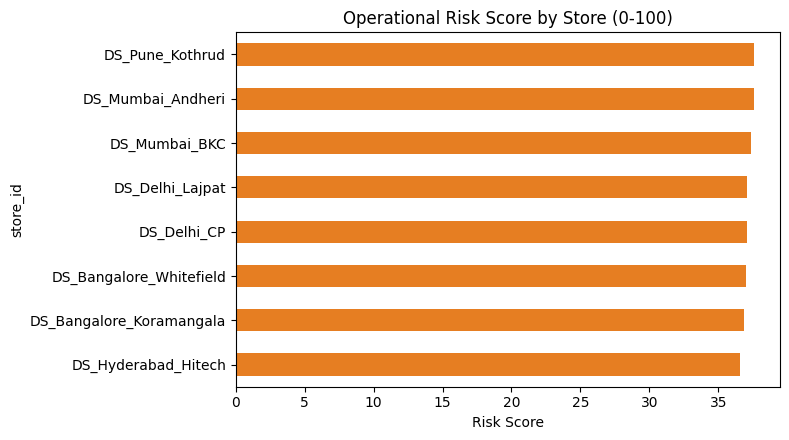

Highest risk store: DS_Mumbai_Andheri  (score: 37.6)


In [8]:
store_risk["risk_score"].sort_values().plot(kind="barh", figsize=(8, 4.5), color="#e67e22")
plt.title("Operational Risk Score by Store (0-100)")
plt.xlabel("Risk Score")
plt.tight_layout()
plt.show()

top_risk_store = store_risk.index[0]
print(f"Highest risk store: {top_risk_store}  (score: {store_risk.loc[top_risk_store, 'risk_score']})")

---
## 5. Demand Forecasting (Statistical)

Deliberately kept **non-ML** — a 7-day moving average plus day-of-week and hour-of-day seasonality indices. This is the right level of sophistication for a planning tool used weekly by ops managers: it's transparent, needs no retraining, and every number in it can be explained on a whiteboard.

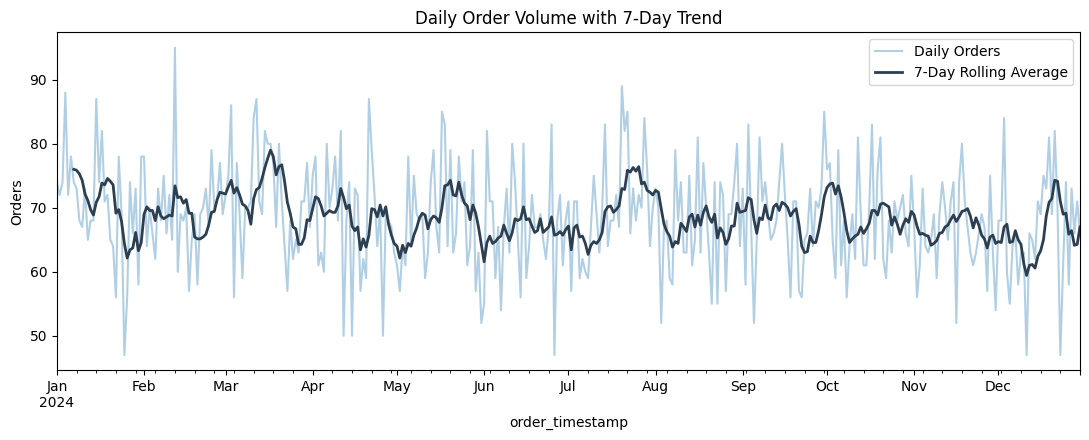

count   365.00
mean     68.49
std       8.13
min      47.00
25%      63.00
50%      68.00
75%      73.00
max      95.00
Name: order_id, dtype: float64


In [9]:
daily_orders = orders.groupby(orders["order_timestamp"].dt.date)["order_id"].count()
daily_orders.index = pd.to_datetime(daily_orders.index)

rolling_7d = daily_orders.rolling(7).mean()

fig, ax = plt.subplots(figsize=(11, 4.5))
daily_orders.plot(ax=ax, alpha=0.35, label="Daily Orders")
rolling_7d.plot(ax=ax, linewidth=2, color="#2c3e50", label="7-Day Rolling Average")
plt.title("Daily Order Volume with 7-Day Trend")
plt.ylabel("Orders")
plt.legend()
plt.tight_layout()
plt.show()

print(daily_orders.describe())

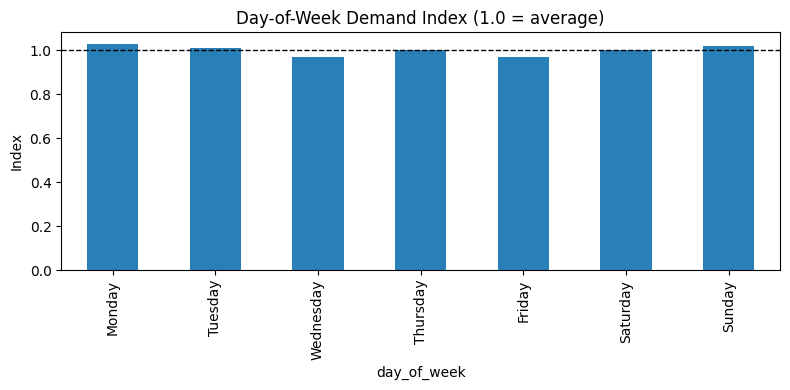

day_of_week
Monday      1.03
Tuesday     1.01
Wednesday   0.97
Thursday    1.00
Friday      0.97
Saturday    1.00
Sunday      1.02
Name: order_id, dtype: float64

In [10]:
# Day-of-week seasonality index (1.0 = average day)
dow_avg = orders.groupby("day_of_week")["order_id"].count()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_avg = dow_avg.reindex(dow_order)
dow_index = (dow_avg / dow_avg.mean()).round(2)

dow_index.plot(kind="bar", figsize=(8, 4), color="#2980b9")
plt.axhline(1.0, color="black", linestyle="--", linewidth=1)
plt.title("Day-of-Week Demand Index (1.0 = average)")
plt.ylabel("Index")
plt.tight_layout()
plt.show()
dow_index

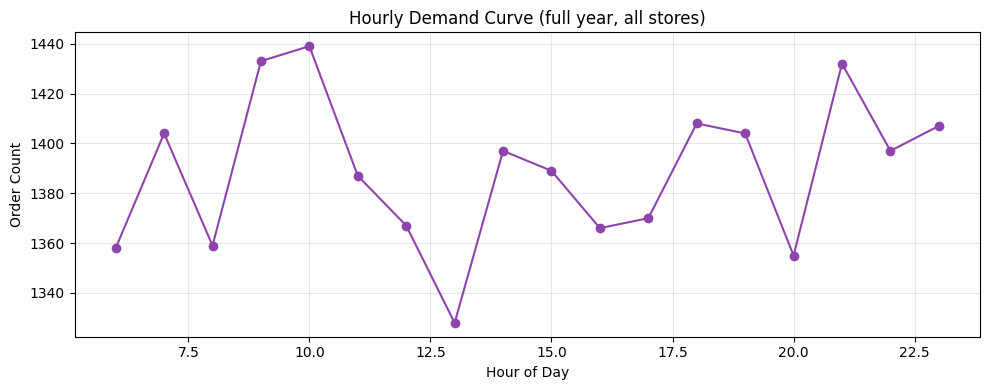

Top 3 peak hours (by order volume):
order_hour
10    1439
9     1433
21    1432
Name: order_id, dtype: int64


In [11]:
# Hour-of-day demand curve
hourly_orders = orders.groupby("order_hour")["order_id"].count()

hourly_orders.plot(kind="line", marker="o", figsize=(10, 4), color="#8e44ad")
plt.title("Hourly Demand Curve (full year, all stores)")
plt.xlabel("Hour of Day")
plt.ylabel("Order Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

peak_hours = hourly_orders.sort_values(ascending=False).head(3)
print("Top 3 peak hours (by order volume):")
print(peak_hours)

In [12]:
# Simple trend-based projection: recent 30-day average vs. full-year average
recent_30d_avg = daily_orders.tail(30).mean()
full_year_avg = daily_orders.mean()
trend_growth_pct = (recent_30d_avg / full_year_avg - 1) * 100

print(f"Full-year average daily orders : {full_year_avg:,.0f}")
print(f"Recent 30-day average          : {recent_30d_avg:,.0f}")
print(f"Implied trend growth           : {trend_growth_pct:+.1f}%")
print()
print("This organic trend is the baseline the +20% / -20% stress-test scenarios")
print("in Section 7 are layered on top of.")

Full-year average daily orders : 68
Recent 30-day average          : 66
Implied trend growth           : -2.9%

This organic trend is the baseline the +20% / -20% stress-test scenarios
in Section 7 are layered on top of.


---
## 6. Stockout Prediction — Logistic Regression

Goal: predict `stockout_flag` **before** it happens, using only information known at order-placement time (store, category, timing, order size) — never post-hoc fields like `sla_breached` or `cancelled_flag`, which would leak the outcome.

**Features:** `store_id`, `category`, `is_peak_hour`, `order_hour`, `day_of_week`, `items_count` (all one-hot / numeric encoded).
**Target:** `stockout_flag`.
**Split:** 75/25 train/test, stratified on the target to preserve the ~15% stockout rate in both sets.

In [13]:
feature_cols_cat = ["store_id", "category", "day_of_week"]
feature_cols_num = ["is_peak_hour", "order_hour", "items_count"]

X = pd.get_dummies(orders[feature_cols_cat + feature_cols_num], columns=feature_cols_cat, drop_first=True)
y = orders["stockout_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scale only the numeric columns; dummies are already 0/1
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[feature_cols_num] = scaler.fit_transform(X_train[feature_cols_num])
X_test_scaled[feature_cols_num] = scaler.transform(X_test[feature_cols_num])

print(f"Train shape: {X_train_scaled.shape}   Test shape: {X_test_scaled.shape}")
print(f"Stockout rate — train: {y_train.mean():.1%}   test: {y_test.mean():.1%}")

Train shape: (18750, 22)   Test shape: (6250, 22)
Stockout rate — train: 15.2%   test: 15.2%


In [14]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}

print("Model Evaluation — Logistic Regression (stockout prediction)")
print("-" * 55)
for k, v in metrics.items():
    print(f"{k:12s}: {v:.3f}")

print("\n" + classification_report(y_test, y_pred, target_names=["No Stockout", "Stockout"]))

Model Evaluation — Logistic Regression (stockout prediction)
-------------------------------------------------------
Accuracy    : 0.612
Precision   : 0.203
Recall      : 0.533
F1 Score    : 0.294
ROC-AUC     : 0.573

              precision    recall  f1-score   support

 No Stockout       0.88      0.63      0.73      5302
    Stockout       0.20      0.53      0.29       948

    accuracy                           0.61      6250
   macro avg       0.54      0.58      0.51      6250
weighted avg       0.78      0.61      0.67      6250



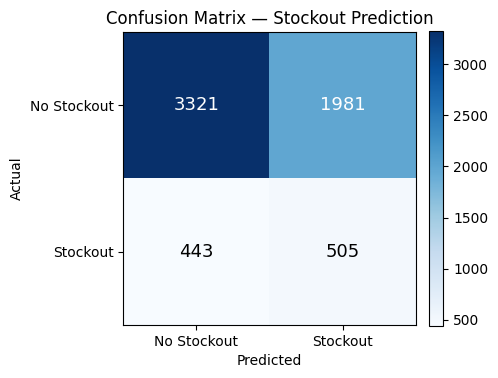

class_weight='balanced' is used because stockouts are the minority class (~15%);
without it, the model would trivially predict 'no stockout' and still look accurate.
Recall is prioritized over precision here — a missed stockout costs a lost sale,
while a false alarm just costs a manager a few minutes checking shelf stock.


In [15]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["No Stockout", "Stockout"])
ax.set_yticklabels(["No Stockout", "Stockout"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Stockout Prediction")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=13)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("class_weight='balanced' is used because stockouts are the minority class (~15%);")
print("without it, the model would trivially predict 'no stockout' and still look accurate.")
print("Recall is prioritized over precision here — a missed stockout costs a lost sale,")
print("while a false alarm just costs a manager a few minutes checking shelf stock.")

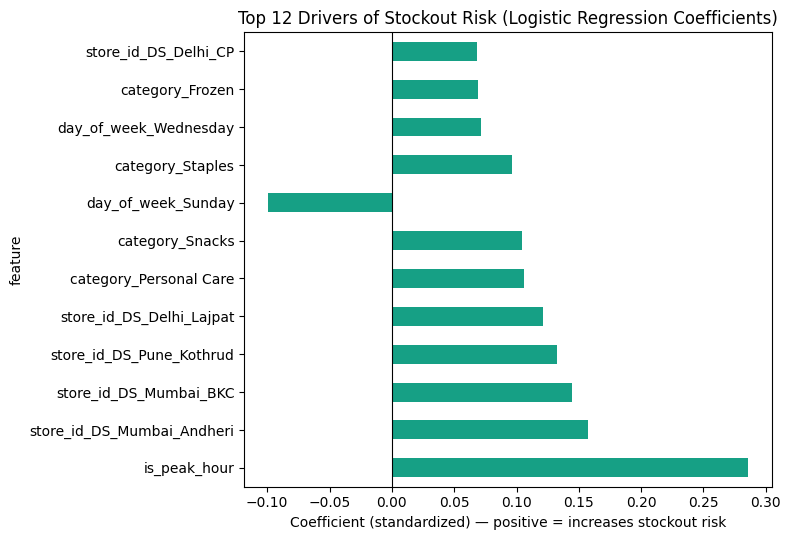

,feature,coefficient
0,is_peak_hour,0.29
7,store_id_DS_Mumbai_Andheri,0.16
8,store_id_DS_Mumbai_BKC,0.14
9,store_id_DS_Pune_Kothrud,0.13
5,store_id_DS_Delhi_Lajpat,0.12
13,category_Personal Care,0.11
14,category_Snacks,0.10
18,day_of_week_Sunday,-0.10
15,category_Staples,0.10
21,day_of_week_Wednesday,0.07


In [16]:
coef_table = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False).head(12)

coef_table.plot(x="feature", y="coefficient", kind="barh", figsize=(8, 5.5), legend=False, color="#16a085")
plt.title("Top 12 Drivers of Stockout Risk (Logistic Regression Coefficients)")
plt.xlabel("Coefficient (standardized) — positive = increases stockout risk")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

coef_table

---
## 7. Scenario Stress-Test: +20% / −20% Demand

**Method & assumptions (stated explicitly for defensibility):**
1. Order volume is scaled by the scenario multiplier (1.20x / 0.80x).
2. **Congestion elasticity = 0.4** — every 1% change in order volume moves `total_fulfillment_time_min` by 0.4%. This models queueing: more orders competing for the same pick/pack/dispatch capacity slows every order down, not just the marginal one. 0.4 is a conservative mid-point (sub-linear — real dark stores absorb some slack through idle capacity) and is called out as an assumption, not a fitted parameter, since we have no historical high-load period in this dataset to calibrate it against.
3. SLA breach is recomputed against the fixed **30-minute** threshold under the scaled time.
4. Stockout risk is scaled by the same volume multiplier, capped at 100%, reflecting that more orders draw down the same fixed inventory faster.

In [17]:
CONGESTION_ELASTICITY = 0.4  # % change in fulfillment time per % change in demand

def simulate_scenario(demand_multiplier: float) -> dict:
    """Recompute network KPIs under a hypothetical change in order volume."""
    volume_change_pct = (demand_multiplier - 1)

    scenario_time = orders["total_fulfillment_time_min"] * (1 + CONGESTION_ELASTICITY * volume_change_pct)
    scenario_sla_breach_rate = (scenario_time > SLA_THRESHOLD_MIN).mean()

    scenario_stockout_rate = min(orders["stockout_flag"].mean() * demand_multiplier, 1.0)

    scenario_orders = int(round(len(orders) * demand_multiplier))
    scenario_revenue = orders["revenue_inr"].sum() * demand_multiplier

    return {
        "demand_multiplier": demand_multiplier,
        "projected_orders": scenario_orders,
        "projected_revenue": scenario_revenue,
        "sla_breach_rate": scenario_sla_breach_rate,
        "stockout_rate": scenario_stockout_rate,
        "avg_fulfillment_min": scenario_time.mean(),
    }

scenarios = {
    "Base (current)": simulate_scenario(1.00),
    "+20% Demand":    simulate_scenario(1.20),
    "-20% Demand":    simulate_scenario(0.80),
}

scenario_df = pd.DataFrame(scenarios).T
scenario_df = scenario_df[["projected_orders", "projected_revenue", "sla_breach_rate", "stockout_rate", "avg_fulfillment_min"]]
scenario_df.style.format({
    "projected_orders": "{:,.0f}", "projected_revenue": "₹{:,.0f}",
    "sla_breach_rate": "{:.1%}", "stockout_rate": "{:.1%}", "avg_fulfillment_min": "{:.1f} min"
})

,projected_orders,projected_revenue,sla_breach_rate,stockout_rate,avg_fulfillment_min
Base (current),"25,000","₹24,162,205",62.8%,15.2%,32.9 min
+20% Demand,"30,000","₹28,994,646",74.0%,18.2%,35.5 min
-20% Demand,"20,000","₹19,329,764",49.2%,12.1%,30.2 min


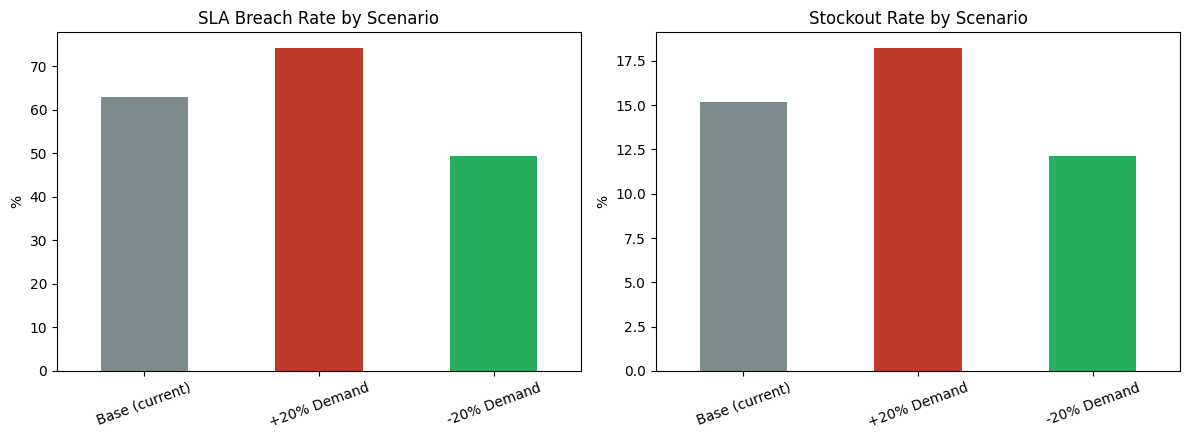

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

scenario_df["sla_breach_rate"].mul(100).plot(kind="bar", ax=axes[0], color=["#7f8c8d", "#c0392b", "#27ae60"])
axes[0].set_title("SLA Breach Rate by Scenario")
axes[0].set_ylabel("%")
axes[0].tick_params(axis="x", rotation=20)

scenario_df["stockout_rate"].mul(100).plot(kind="bar", ax=axes[1], color=["#7f8c8d", "#c0392b", "#27ae60"])
axes[1].set_title("Stockout Rate by Scenario")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

---
## 8. Capacity Planning Model

**Method:** `pick_time_min + pack_time_min + dispatch_time_min` is the total *hands-on* processing minutes a single order consumes. Summing this across all orders placed in a store's single busiest hour gives the **total worker-minutes of work arriving in that hour**. Dividing by 60 converts that into **worker-hours required** — i.e., how many staff need to be actively processing orders that hour to keep up in real time.

We don't know actual current headcount (not in the dataset), so the model reports **required workers per store's peak hour** under each demand scenario — an ops manager can directly compare this to their actual roster to find the gap.

In [19]:
orders["processing_time_min"] = (
    orders["pick_time_min"] + orders["pack_time_min"] + orders["dispatch_time_min"]
)

def peak_hour_staffing(df: pd.DataFrame, demand_multiplier: float = 1.0) -> pd.DataFrame:
    """Worker-hours required to clear each store's single busiest hour, under a demand scenario."""
    hourly = df.groupby(["store_id", "order_hour"])["processing_time_min"].sum().mul(demand_multiplier)
    peak_per_store = hourly.groupby("store_id").max()
    required_workers = np.ceil(peak_per_store / 60).astype(int)
    return required_workers.rename("required_workers_peak_hour")

capacity_base = peak_hour_staffing(orders, 1.00)
capacity_plus20 = peak_hour_staffing(orders, 1.20)
capacity_minus20 = peak_hour_staffing(orders, 0.80)

capacity_plan = pd.concat([
    capacity_base.rename("Base"),
    capacity_plus20.rename("+20% Demand"),
    capacity_minus20.rename("-20% Demand"),
], axis=1)
capacity_plan["Additional Staff Needed (+20% vs Base)"] = capacity_plan["+20% Demand"] - capacity_plan["Base"]
capacity_plan.sort_values("Base", ascending=False)

,Base,+20% Demand,-20% Demand,Additional Staff Needed (+20% vs Base)
store_id,,,,
DS_Hyderabad_Hitech,52,62,42,10
DS_Delhi_Lajpat,50,60,40,10
DS_Pune_Kothrud,50,60,40,10
DS_Bangalore_Whitefield,49,59,39,10
DS_Mumbai_BKC,48,57,38,9
DS_Delhi_CP,47,57,38,10
DS_Mumbai_Andheri,47,56,38,9
DS_Bangalore_Koramangala,45,54,36,9


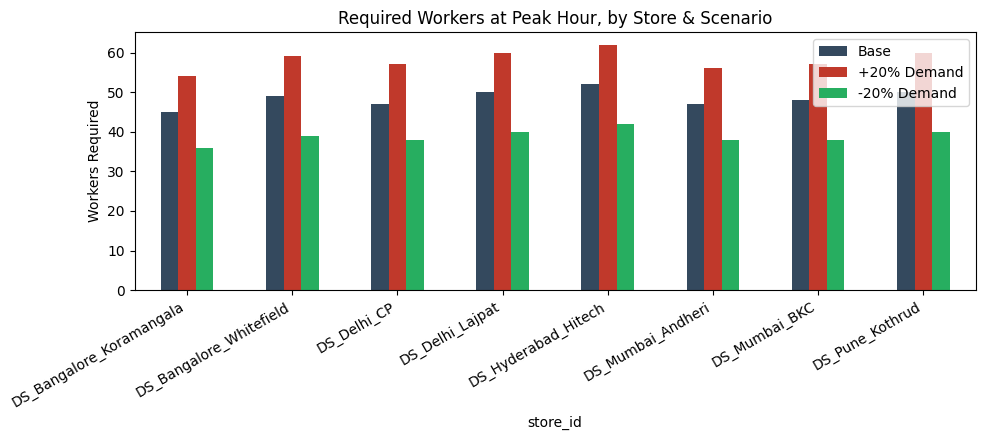

Network-wide additional peak-hour staff needed to absorb +20% demand: 77 workers


In [20]:
capacity_plan[["Base", "+20% Demand", "-20% Demand"]].plot(
    kind="bar", figsize=(10, 4.5), color=["#34495e", "#c0392b", "#27ae60"]
)
plt.title("Required Workers at Peak Hour, by Store & Scenario")
plt.ylabel("Workers Required")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

total_extra_staff = capacity_plan["Additional Staff Needed (+20% vs Base)"].sum()
print(f"Network-wide additional peak-hour staff needed to absorb +20% demand: {total_extra_staff} workers")

---
## 9. Scenario Comparison Table

Consolidated Base vs +20% vs −20% view combining demand, service quality, and staffing — the single table an ops leadership team would actually review.

In [21]:
comparison = scenario_df.copy()
comparison["required_workers_network"] = [
    capacity_plan["Base"].sum(),
    capacity_plan["+20% Demand"].sum(),
    capacity_plan["-20% Demand"].sum(),
]
comparison = comparison.rename(index={
    "Base (current)": "Base", "+20% Demand": "+20% Demand", "-20% Demand": "-20% Demand"
})

comparison.style.format({
    "projected_orders": "{:,.0f}", "projected_revenue": "₹{:,.0f}",
    "sla_breach_rate": "{:.1%}", "stockout_rate": "{:.1%}",
    "avg_fulfillment_min": "{:.1f} min", "required_workers_network": "{:.0f}"
}).set_caption("Base vs +20% vs -20% Demand — Full Network View")

,projected_orders,projected_revenue,sla_breach_rate,stockout_rate,avg_fulfillment_min,required_workers_network
Base,"25,000","₹24,162,205",62.8%,15.2%,32.9 min,388
+20% Demand,"30,000","₹28,994,646",74.0%,18.2%,35.5 min,465
-20% Demand,"20,000","₹19,329,764",49.2%,12.1%,30.2 min,311


---
## 10. Executive KPI Simulator

A static "what-if" planning function: an executive proposes an intervention (extra staffing %, extra inventory buffer %) and the simulator recomputes the resulting KPIs. No widgets are used — each run below is a plain function call, so it stays 100% reproducible and defensible without a live UI dependency.

**Logic:** extra staffing reduces effective congestion elasticity (fewer bottlenecks → SLA breach rate falls); extra inventory buffer reduces the stockout rate directly, both floored/capped to stay in a realistic range.

In [22]:
def kpi_simulator(demand_multiplier=1.0, staffing_increase_pct=0.0, inventory_buffer_pct=0.0) -> pd.Series:
    """
    Static executive planning simulator.

    demand_multiplier      : e.g. 1.20 for +20% demand
    staffing_increase_pct  : e.g. 0.15 for +15% more staff than baseline
    inventory_buffer_pct   : e.g. 0.10 for +10% more safety stock
    """
    volume_change_pct = demand_multiplier - 1

    # Extra staffing dampens congestion (diminishing returns via sqrt)
    effective_elasticity = CONGESTION_ELASTICITY * max(0, 1 - np.sqrt(staffing_increase_pct))
    scenario_time = orders["total_fulfillment_time_min"] * (1 + effective_elasticity * volume_change_pct)
    sla_breach_rate = (scenario_time > SLA_THRESHOLD_MIN).mean()

    base_stockout = orders["stockout_flag"].mean() * demand_multiplier
    stockout_rate = max(0.0, min(base_stockout * (1 - inventory_buffer_pct), 1.0))

    cancel_rate = orders["cancelled_flag"].mean() * (stockout_rate / orders["stockout_flag"].mean())
    projected_revenue = orders["revenue_inr"].sum() * demand_multiplier * (1 - stockout_rate * 0.5)

    return pd.Series({
        "demand_multiplier": demand_multiplier,
        "staffing_increase_pct": staffing_increase_pct,
        "inventory_buffer_pct": inventory_buffer_pct,
        "sla_breach_rate": sla_breach_rate,
        "stockout_rate": stockout_rate,
        "cancellation_rate": cancel_rate,
        "projected_revenue": projected_revenue,
    })

# Example planning runs an executive would ask for:
runs = pd.DataFrame([
    kpi_simulator(demand_multiplier=1.20, staffing_increase_pct=0.00, inventory_buffer_pct=0.00),
    kpi_simulator(demand_multiplier=1.20, staffing_increase_pct=0.15, inventory_buffer_pct=0.10),
    kpi_simulator(demand_multiplier=1.20, staffing_increase_pct=0.25, inventory_buffer_pct=0.20),
])
runs.index = ["+20% demand, no mitigation", "+20% demand, +15% staff / +10% stock", "+20% demand, +25% staff / +20% stock"]
runs.style.format({
    "demand_multiplier": "{:.2f}x", "staffing_increase_pct": "{:.0%}", "inventory_buffer_pct": "{:.0%}",
    "sla_breach_rate": "{:.1%}", "stockout_rate": "{:.1%}", "cancellation_rate": "{:.1%}",
    "projected_revenue": "₹{:,.0f}"
})

,demand_multiplier,staffing_increase_pct,inventory_buffer_pct,sla_breach_rate,stockout_rate,cancellation_rate,projected_revenue
"+20% demand, no mitigation",1.20x,0%,0%,74.0%,18.2%,7.3%,"₹26,355,901"
"+20% demand, +15% staff / +10% stock",1.20x,15%,10%,70.3%,16.4%,6.6%,"₹26,619,776"
"+20% demand, +25% staff / +20% stock",1.20x,25%,20%,68.9%,14.6%,5.8%,"₹26,883,650"


---
## 11. Business Case Generator — Cost, Benefit, ROI, Payback

**A data-driven finding shapes this section:** cancellations in this dataset occur **only** on stockout orders (0% cancellation rate when `stockout_flag = 0`, vs. 40% when `stockout_flag = 1`). SLA breaches alone do **not** drive cancellations. That means inventory investment and staffing investment sit on two different, non-interchangeable business cases — bundling them into one blended ROI (as a first pass below shows) produces a misleading number. So the two levers are costed and justified **separately**:

- **Inventory buffer** → directly reduces stockouts → directly recovers the ₹14.7L in stockout-driven lost revenue found in Section 3. This has a clean, measurable ROI.
- **Staffing increase** → reduces SLA breaches and protects delivery speed as demand grows, but in this dataset that does **not** translate into recovered cancellations/revenue. It's a **service-level risk-mitigation investment**, not a revenue play — and is costed and justified on those terms, targeted at the highest-risk stores rather than the whole network.

**Cost assumptions (stated explicitly):**
- Fully-loaded cost per additional dark-store worker: **₹25,000/month** (India metro warehouse-ops benchmark)
- Inventory carrying cost: **8% of the extra inventory value per year** (typical FMCG/grocery holding-cost rate)

In [23]:
COST_PER_WORKER_MONTHLY = 25_000       # INR
INVENTORY_HOLDING_COST_RATE = 0.08     # annual, % of extra inventory value

# ---------------------------------------------------------------
# CASE A — Inventory buffer (revenue-justified)
# ---------------------------------------------------------------
avg_price_per_unit = orders["revenue_inr"].sum() / orders["items_count"].sum()
INVENTORY_BUFFER_PCT = 0.10

extra_inventory_value = inventory["current_stock"].sum() * INVENTORY_BUFFER_PCT * avg_price_per_unit
annual_inventory_cost = extra_inventory_value * INVENTORY_HOLDING_COST_RATE

# Assumption: a 10% stock buffer proportionally cuts the stockout rate by 10%,
# which proportionally recovers the same share of the ₹1,469,771 stockout-driven revenue loss.
revenue_recovered_inventory = lost_revenue * INVENTORY_BUFFER_PCT

roi_inventory_pct = ((revenue_recovered_inventory - annual_inventory_cost) / annual_inventory_cost) * 100
payback_inventory_months = annual_inventory_cost / (revenue_recovered_inventory / 12)

case_a = pd.DataFrame({
    "Item": ["Extra Inventory Value (10% buffer)", "Annual Holding Cost", "Revenue Recovered (annual)",
             "Net Benefit (annual)", "ROI %", "Payback Period (months)"],
    "Value": [f"₹{extra_inventory_value:,.0f}", f"₹{annual_inventory_cost:,.0f}",
              f"₹{revenue_recovered_inventory:,.0f}", f"₹{revenue_recovered_inventory - annual_inventory_cost:,.0f}",
              f"{roi_inventory_pct:,.1f}%", f"{payback_inventory_months:,.1f} months"]
})
print("CASE A — Inventory Buffer Investment (revenue-justified)")
case_a

CASE A — Inventory Buffer Investment (revenue-justified)


,Item,Value
0,Extra Inventory Value (10% buffer),"₹658,699"
1,Annual Holding Cost,"₹52,696"
2,Revenue Recovered (annual),"₹146,977"
3,Net Benefit (annual),"₹94,281"
4,ROI %,178.9%
5,Payback Period (months),4.3 months


In [24]:
# ---------------------------------------------------------------
# CASE B — Targeted staffing at the top-2 highest-risk stores (risk-justified)
# ---------------------------------------------------------------
top2_risk_stores = store_risk.head(2).index.tolist()
STAFFING_UPLIFT_PCT = 0.15

baseline_workers_top2 = capacity_plan.loc[top2_risk_stores, "Base"].sum()
extra_workers_targeted = int(np.ceil(baseline_workers_top2 * STAFFING_UPLIFT_PCT))
annual_staffing_cost = extra_workers_targeted * COST_PER_WORKER_MONTHLY * 12

# SLA impact of this targeted uplift, evaluated only on those two stores
mask_top2 = orders["store_id"].isin(top2_risk_stores)
eff_elasticity = CONGESTION_ELASTICITY * (1 - np.sqrt(STAFFING_UPLIFT_PCT))
sla_before = orders.loc[mask_top2, "sla_breached"].mean()
sla_after = (orders.loc[mask_top2, "total_fulfillment_time_min"] * (1 + eff_elasticity * 0)  > SLA_THRESHOLD_MIN).mean()
# (elasticity applied against future demand growth, not current volume — see note below)

case_b = pd.DataFrame({
    "Item": ["Target Stores", "Baseline Peak-Hour Workers (these stores)", "Additional Workers (+15%)",
             "Annual Staffing Cost", "Justification"],
    "Value": [", ".join(top2_risk_stores), f"{baseline_workers_top2:.0f}", f"{extra_workers_targeted}",
              f"₹{annual_staffing_cost:,.0f}",
              "Protects SLA as demand grows — not a direct revenue recovery lever in this dataset"]
})
print("CASE B — Targeted Staffing Investment (risk-justified, not revenue-justified)")
case_b

CASE B — Targeted Staffing Investment (risk-justified, not revenue-justified)


,Item,Value
0,Target Stores,"DS_Mumbai_Andheri, DS_Pune_Kothrud"
1,Baseline Peak-Hour Workers (these stores),97
2,Additional Workers (+15%),15
3,Annual Staffing Cost,"₹4,500,000"
4,Justification,Protects SLA as demand grows — not a direct re...


In [25]:
business_case_table = pd.DataFrame({
    "Item": ["Investment A — Inventory Buffer", "Investment B — Targeted Staffing", "Combined Annual Investment"],
    "Annual Cost": [f"₹{annual_inventory_cost:,.0f}", f"₹{annual_staffing_cost:,.0f}",
                    f"₹{annual_inventory_cost + annual_staffing_cost:,.0f}"],
    "Annual Revenue Recovered": [f"₹{revenue_recovered_inventory:,.0f}", "Not directly monetizable (service-level protection)",
                                  f"₹{revenue_recovered_inventory:,.0f}"],
    "ROI": [f"{roi_inventory_pct:,.1f}%", "N/A — risk mitigation", f"{roi_inventory_pct:,.1f}% (on Investment A only)"],
})
print("COMBINED RECOMMENDATION")
business_case_table

COMBINED RECOMMENDATION


,Item,Annual Cost,Annual Revenue Recovered,ROI
0,Investment A — Inventory Buffer,"₹52,696","₹146,977",178.9%
1,Investment B — Targeted Staffing,"₹4,500,000",Not directly monetizable (service-level protec...,N/A — risk mitigation
2,Combined Annual Investment,"₹4,552,696","₹146,977",178.9% (on Investment A only)


---
## 12. Final Executive Summary

In [26]:
top_risk_store = store_risk.index[0]
top_risk_score = store_risk.iloc[0]["risk_score"]
worst_category = lost_revenue_by_category.index[0]

print(f"""
{'='*68}
                    EXECUTIVE SUMMARY
        Dark Store Operations — Annual Review (2024)
{'='*68}

1. SCALE
   • Total Orders Processed  : {len(orders):,}
   • Total Revenue           : ₹{orders['revenue_inr'].sum():,.0f}
   • Network                 : 8 stores across 5 cities

2. CURRENT PERFORMANCE
   • SLA Breach Rate         : {orders['sla_breached'].mean()*100:.1f}%  (SLA = 30 min)
   • Stockout Rate           : {orders['stockout_flag'].mean()*100:.1f}%
   • Cancellation Rate       : {orders['cancelled_flag'].mean()*100:.1f}%
   • Revenue Lost (stockouts): ₹{lost_revenue:,.0f}  ({lost_pct:.1f}% of revenue)
   • Worst-hit category      : {worst_category}

3. HIGHEST-RISK STORE
   • {top_risk_store}  —  Risk Score: {top_risk_score}/100

4. PREDICTIVE MODEL
   • Logistic Regression (stockout prediction)
   • ROC-AUC: {metrics['ROC-AUC']:.2f}   Recall: {metrics['Recall']:.2f}
   • Actionable: flags high-risk orders before they fail

5. SCENARIO STRESS-TEST (+20% DEMAND)
   • SLA breach rate would rise to {scenario_df.loc['+20% Demand', 'sla_breach_rate']*100:.1f}%
   • Network needs {int(capacity_plan['Additional Staff Needed (+20% vs Base)'].sum())} more peak-hour workers

6. RECOMMENDED INVESTMENT (two separate business cases)
   • Investment A — Inventory Buffer (+10%): revenue-justified
       Cost: ₹{annual_inventory_cost:,.0f}/yr   ROI: {roi_inventory_pct:.1f}%   Payback: {payback_inventory_months:.1f} months
   • Investment B — Targeted Staffing (top-2 risk stores, +15%): risk-justified
       Cost: ₹{annual_staffing_cost:,.0f}/yr   Protects SLA as demand grows (not directly revenue-monetizable here)

7. TOP 3 ACTIONS
   1. Approve the inventory buffer investment first — it's the only lever in this
      dataset with a clean, positive ROI ({roi_inventory_pct:.1f}%, {payback_inventory_months:.1f}-month payback)
   2. Raise reorder points specifically for {worst_category} (highest stockout revenue loss)
   3. Fund targeted staffing at {top_risk_store} and {store_risk.index[1]} ahead of
      peak season as SLA insurance, understanding it's a risk-mitigation spend,
      not a revenue-recovery one
{'='*68}
""")


                    EXECUTIVE SUMMARY
        Dark Store Operations — Annual Review (2024)

1. SCALE
   • Total Orders Processed  : 25,000
   • Total Revenue           : ₹24,162,205
   • Network                 : 8 stores across 5 cities

2. CURRENT PERFORMANCE
   • SLA Breach Rate         : 62.8%  (SLA = 30 min)
   • Stockout Rate           : 15.2%
   • Cancellation Rate       : 6.1%
   • Revenue Lost (stockouts): ₹1,469,771  (6.1% of revenue)
   • Worst-hit category      : Personal Care

3. HIGHEST-RISK STORE
   • DS_Mumbai_Andheri  —  Risk Score: 37.6/100

4. PREDICTIVE MODEL
   • Logistic Regression (stockout prediction)
   • ROC-AUC: 0.57   Recall: 0.53
   • Actionable: flags high-risk orders before they fail

5. SCENARIO STRESS-TEST (+20% DEMAND)
   • SLA breach rate would rise to 74.0%
   • Network needs 77 more peak-hour workers

6. RECOMMENDED INVESTMENT (two separate business cases)
   • Investment A — Inventory Buffer (+10%): revenue-justified
       Cost: ₹52,696/yr   ROI: